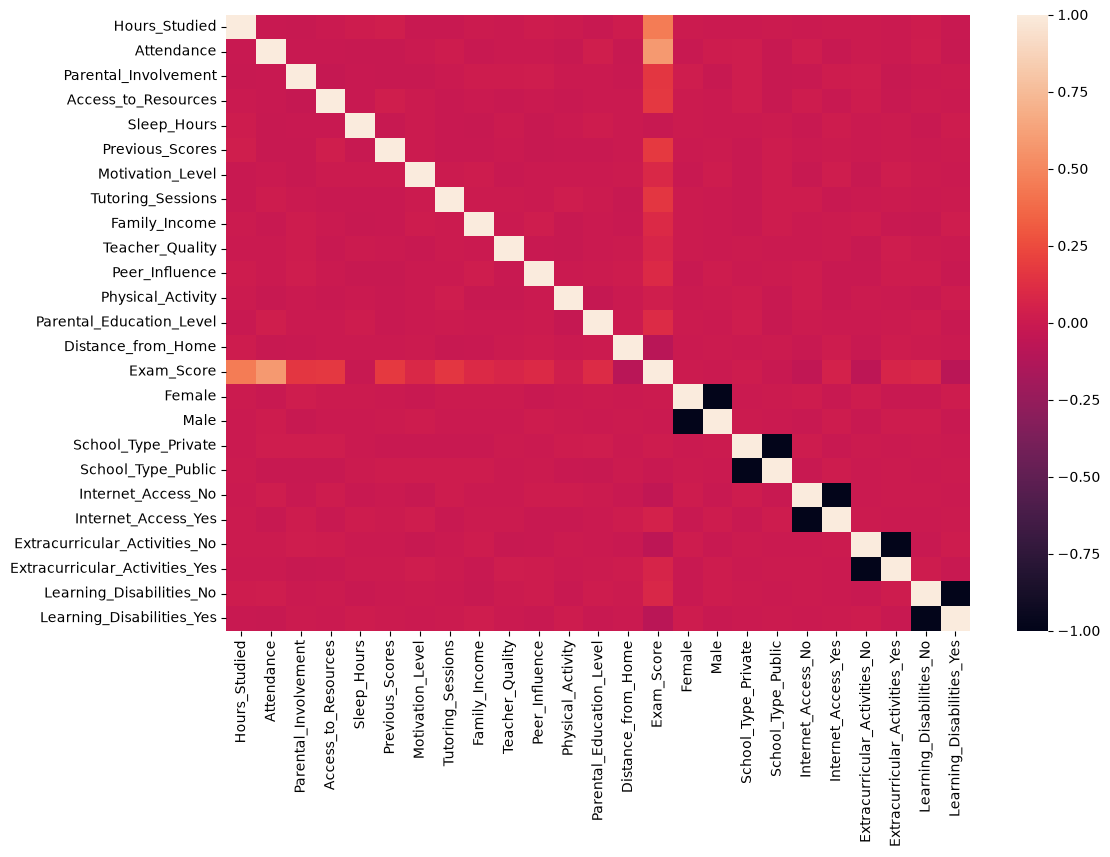

------evaluation metrices of linear Regression Model------
Lr_MAE =  0.4482761353800866
Lr_MSE =  3.336771732914763
Lr_RMSE =  1.8266832601506926
Lr_r2_score =  0.7717200823165442
-------------------------------------------------------
---------Scatter plot----------


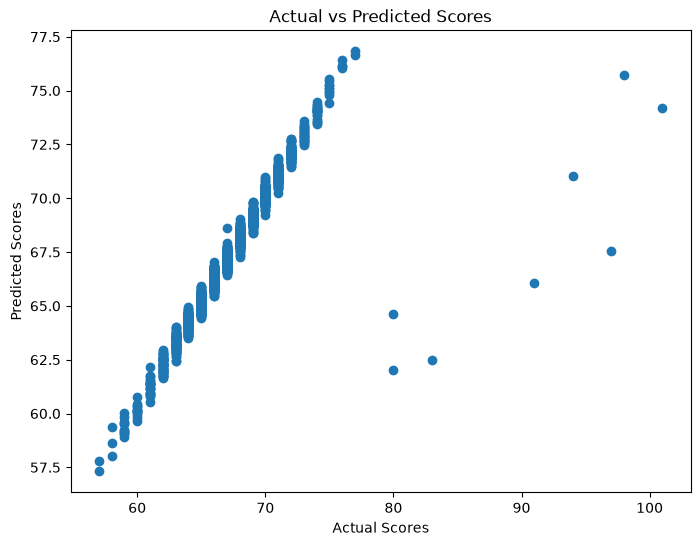

Model Saved Successfully


In [21]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Dataset/StudentPerformanceFactors.csv") 
# print(os.getcwd())
# print(os.listdir())
# print(df.shape)   # tells the row and columns
# print(df.size)   # totol number of elements (row X column)
# print(df.head()) # give first five rows 
# print(df.tail())  # give last five rows
# print(df.columns)
# df.info()
# print(df.isnull().sum())
# print(df.duplicated().sum())
# for col in df.select_dtypes(include='object').columns:
#   print("\n",col)
#   print(df[col].unique())

# print(df["Teacher_Quality"].mode())
# print(df["Parental_Education_Level"].mode())
# print(df["Distance_from_Home"].mode())
df["Teacher_Quality"] = df["Teacher_Quality"].fillna("Medium")
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna("High School")
df["Distance_from_Home"] = df["Distance_from_Home"].fillna("Near")
# print(df.isnull().sum())
mapping ={
  "Low":0,
  "Medium":1,
  "High":2
}

df["Motivation_Level"]  = df["Motivation_Level"].map(mapping)
# print(df["Motivation_Level"].unique())

df["Teacher_Quality"]  = df["Teacher_Quality"].map(mapping)
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(1)
df["Teacher_Quality"] = df["Teacher_Quality"].astype(int)
# print(df["Teacher_Quality"].unique())

df["Parental_Involvement"]  = df["Parental_Involvement"].map(mapping)
# print(df["Parental_Involvement"].unique())

df["Access_to_Resources"]  = df["Access_to_Resources"].map(mapping)
# print(df["Access_to_Resources"].unique())

df["Family_Income"]  = df["Family_Income"].map(mapping)
# print(df["Family_Income"].unique())



Peer_Influence_mapping ={
  "Negative":0,
  "Neutral":1,
  "Positive":2
  
}
df["Peer_Influence"] = df["Peer_Influence"].map(Peer_Influence_mapping)
# print(df["Peer_Influence"].unique())

Parental_Education_Level_mapping = {
  "High School":0,
  "College":1,
  "Postgraduate":2
}
df["Parental_Education_Level"] = df["Parental_Education_Level"].map(Parental_Education_Level_mapping)
# print(df["Parental_Education_Level"].unique())

Distance_from_Home_mapping = {
   "Near": 0,
   "Moderate":1,
   "Far":2
 }

df["Distance_from_Home"] = df["Distance_from_Home"].map(Distance_from_Home_mapping)
# print(df["Distance_from_Home"].unique())

gender_encode = pd.get_dummies(df["Gender"],dtype=int) 
# print(gender_encode.head())

df = pd.concat([df,gender_encode], axis= 1)  # axis 1 -> column wise  (here joined dataframes )

df = df.drop("Gender",axis=1)  # this is used to drop entire Gender columns
# print(df.head())
# print(df.shape)

nominal_columns = [
  "School_Type",
  "Internet_Access",
  "Extracurricular_Activities",
  "Learning_Disabilities"
]
df = pd.get_dummies(df,columns=nominal_columns,dtype=int)
 
# df.columns
# print(df.head())


# df.describe().T
# plt.figure(figsize=(8,5))
# plt.hist(df["Exam_Score"])
# plt.title("Distribution of Exam Scores")
# plt.xlabel("Exam Score")
# plt.ylabel("Number of Students")
# plt.show()
# df["Exam_Score"].hist()


correlation = df.corr(numeric_only=True)
# print(correlation["Exam_Score"].sort_values(ascending=False))

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True))

plt.show()

X = df.drop("Exam_Score",axis=1)
Y = df["Exam_Score"]

# print(X.shape)

# print(Y.shape)

from sklearn.model_selection import train_test_split

X_train , X_test, Y_train,Y_test = train_test_split(
  X,
  Y,
  test_size=0.2,
  random_state=23
)

# print(X_train.shape)
# print(X_test.shape)
# print(Y_train.shape)
# print(Y_test.shape)


from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train , Y_train)

predictions = model.predict(X_test)



# print(predictions.shape)

# comaprison between actual score and predicted score
# print("Actual Scores:")
# print(Y_test[:12])

# print("\nPredicted Scores:")
# print(predictions[:12])


print("------evaluation metrices of linear Regression Model------")
from sklearn.metrics import (
  mean_absolute_error,
  mean_squared_error,
  root_mean_squared_error,
  r2_score
)

lr_mae = mean_absolute_error(
  Y_test,
  predictions
)
print("Lr_MAE = ",lr_mae)

lr_mse = mean_squared_error(
  Y_test,
  predictions
)
print("Lr_MSE = ", lr_mse)

lr_rmse = root_mean_squared_error(
  Y_test,
  predictions
)
print("Lr_RMSE = ",lr_rmse)

lr_r2 = r2_score(
  Y_test, 
  predictions
)
print("Lr_r2_score = ", lr_r2)

print("-------------------------------------------------------")

print("---------Scatter plot----------")
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(Y_test, predictions)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")

plt.show()

# print(X.columns.tolist())

# for col in df.select_dtypes(include='object').columns:
#   print("\n",col)
#   print(df[col].unique())
  
  
import joblib

joblib.dump(model, "student_score_model.pkl")

print("Model Saved Successfully")
  


-------scatter plot between hours study and exam_score---------


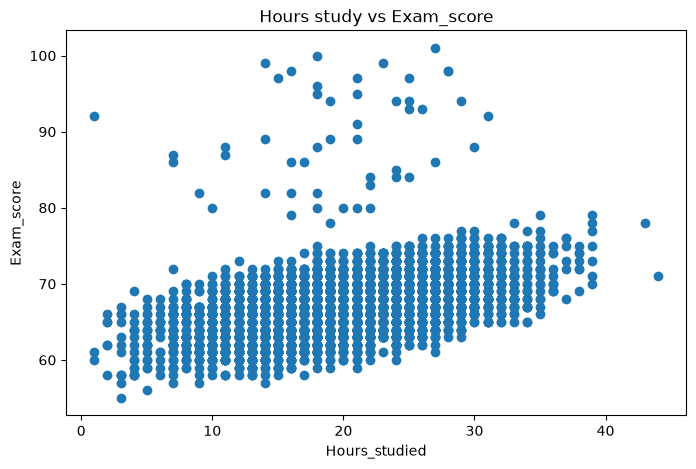

In [32]:
print("-------scatter plot between hours study and exam_score---------")
plt.figure(figsize=(8,5))
plt.scatter(
  df["Hours_Studied"],
   df["Exam_Score"]
)
plt.xlabel("Hours_studied")
plt.ylabel("Exam_score")

plt.title("Hours study vs Exam_score")
plt.show()

-------scatter plot between Attendance and exam_score-------


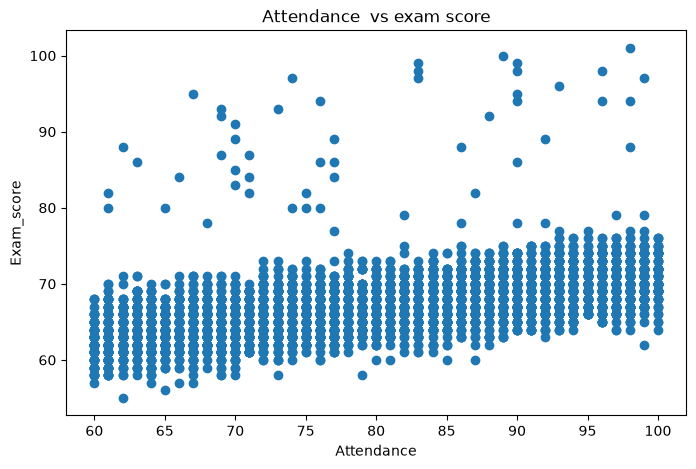

In [33]:
print("-------scatter plot between Attendance and exam_score-------")

plt.figure(figsize=(8,5))
plt.scatter(
  df["Attendance"],
  df["Exam_Score"]
)
plt.xlabel("Attendance")
plt.ylabel("Exam_score")
plt.title("Attendance  vs exam score")
plt.show()

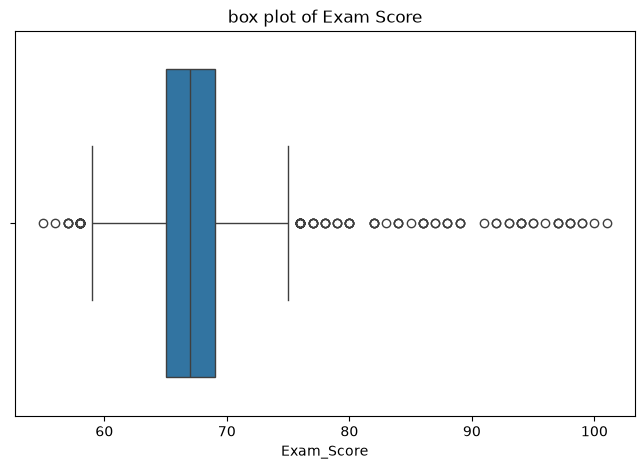

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Exam_Score"])
plt.title("box plot of Exam Score")
plt.show()





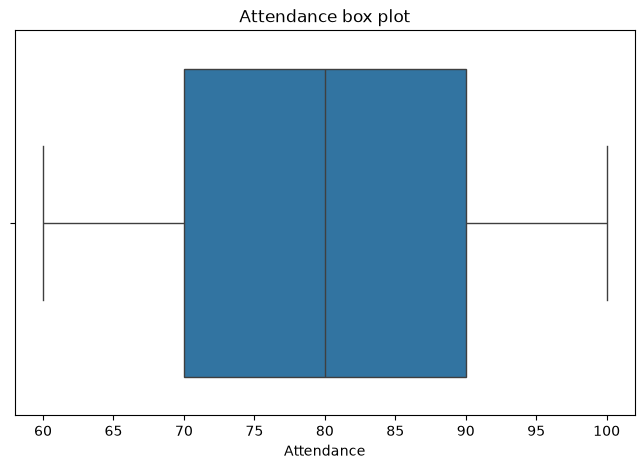

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x = df["Attendance"])
plt.title("Attendance box plot")
plt.show()


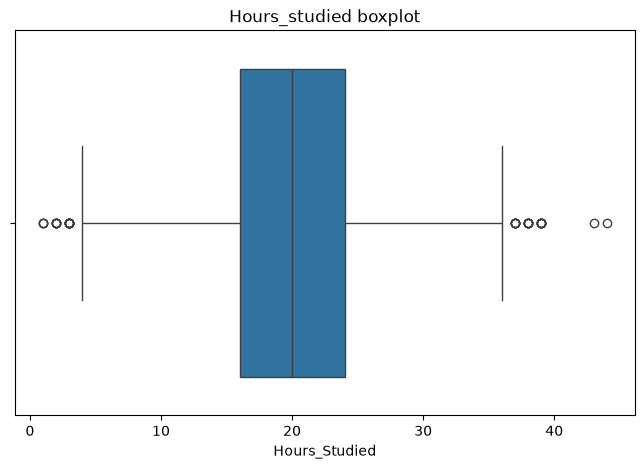

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.boxplot(x = df["Hours_Studied"])
plt.title("Hours_studied boxplot")
plt.show()

In [3]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
  n_estimators=100,
  random_state=42
)
rf_model.fit(
  X_train,
  Y_train
)

rf_predictions = rf_model.predict(X_test)

print(rf_predictions.shape)


(1322,)


In [7]:
from sklearn.metrics import (
  mean_absolute_error,
  mean_squared_error,
  root_mean_squared_error,
  r2_score
)
print("---------Evaluation metrices of Random Forest Model---------")
rf_mae = mean_absolute_error(
  Y_test,
  rf_predictions
)
print("RF MAE = ", rf_mae)

rf_mse = mean_squared_error(
Y_test,
rf_predictions)
print("RF_RSE = ", rf_mse)

rf_rmse = root_mean_squared_error(
  Y_test,
  rf_predictions
)
print("RF_RMSE = ",rf_rmse)

rf_r2 = r2_score(
  Y_test,
  rf_predictions
  
)
print("RF_r2_score = ", rf_r2)
print("-------------------------------------------------------------")

---------Evaluation metrices of Random Forest Model---------
RF MAE =  1.1188124054462936
RF_RSE =  4.83510915279879
RF_RMSE =  2.1988881628674957
RF_r2_score =  0.6692137168078718
-------------------------------------------------------------


In [12]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
n_estimators = 100,
learnig_rate = 0.1,
nax_depth = 5,
random_state = 42
)
xgb_model.fit(
  X_train,
  Y_train
)
xgb_predictions = xgb_model.predict(
  X_test
)
print(xgb_predictions.shape)

(1322,)


In [16]:
from sklearn.metrics import (
  mean_absolute_error,
  mean_squared_error,
  root_mean_squared_error,
  r2_score
)
print("------Evaluation metices of XGboost model------")
xgb_mae = mean_absolute_error(
  Y_test,
  xgb_predictions
)
print("XGB_MAE = ", xgb_mae)
xgb_mse = mean_squared_error(
  Y_test,
  xgb_predictions
)
print("XGB_MSE = ", xgb_mse)
xgb_rmse = root_mean_squared_error(
  Y_test,
  xgb_predictions
)
print("XGB_RMSE = ", xgb_rmse)
xgb_r2 = r2_score(
  Y_test,
  xgb_predictions
)
print("XGB_R2_score = ", xgb_r2)
print("--------------------------------------------------")

------Evaluation metices of XGboost model------
XGB_MAE =  0.9576261043548584
XGB_MSE =  4.713196277618408
XGB_RMSE =  2.170989751815796
XGB_R2_score =  0.6775541305541992
--------------------------------------------------
